<a href="https://colab.research.google.com/github/raelynnedelamasa/musicComputing/blob/main/assignments/labAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import matplotlib.pylab as plt
import librosa.display
import IPython.display
import librosa

In [24]:
def plotAudio2(sig,sampleRate,numHarmonics):

    # from Assignment 2/Google Doc
    time=np.arange(0,sig.shape[0])/sampleRate
    excursion=max(abs(sig))
    sigNew = sig / excursion

    xlabel = 'Time (seconds)'
    ylabel = 'Amplitude'

    plt.plot(time,sigNew)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [25]:
def plotAudioFreqDomain(sig,frequency,samplingRate,numHarmonics,winSize,specType,waveType):

    # from Assignment 3
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(spec, y_axis='linear',sr = samplingRate)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Linear-frequency power spectrogram')
    plt.show()

In [26]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):

   # from additiveSynthesis.ipynb
   # generate list of harmonics
   harmonics = np.arange(1,numHarmonics+1,seqHarm)
   harmonics = harmonics[1:-1]

   # create a time series from 0 to 1 the inputted length
   timeSeries = np.linspace(0, 1, samplingRate)

   # create a cosine wave for the fundamental
   sig = np.cos(2.0 * np.pi * frequency * timeSeries)

   # add harmonics based on the those specified in the variable 'harmonics'
   for harm in harmonics:
    sig = sig + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

   # scale the signal to between -1 and 1
   excursion=max(abs(sig))
   sig = sig / excursion

   # plot signal
   plt.plot(timeSeries,sig)
   plt.xlabel('Time (Sec)')
   plt.ylabel('Amplitude')
   plt.title('Additive Synthesis')
   plt.plot

   return sig

In [27]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):
    # use an if/elif/else statement to set up the parameters for
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipynb
    # if, elif (else if) and else can be used to evaluate the contents of a variable

# if, elif (else if) and else can be used to evaluate the contents of a variable

    if waveType == 'sawtooth':
      seqHarm = 1
      ampExponent = 1
    elif waveType == 'square':
      seqHarm = 2
      ampExponent = 1
    elif waveType == 'triangle':
      seqHarm = 2
      ampExponent = 2
    else:
      numHarmonics = 1
      seqHarm = 1
      ampExponent = 1

    # call additiveSynthesis() to generate a waveform
    sig = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)

    # return the generated waveform (signal)
    return sig

In [28]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize, specType):
  # call makeWaveform()
  sig = makeWaveforms(frequency,samplingRate,numHarmonics,waveType)
  # test whether makeWaveforms() runs without error before you try plotting anything

  # call plotAudio2()
  plotAudio2(sig,samplingRate,numHarmonics)

  # call plotAudioFreqDomain()
  plotAudioFreqDomain(sig,frequency, samplingRate,numHarmonics,winSize,specType,waveType)

  # return the output of makeWaveform()
  return sig

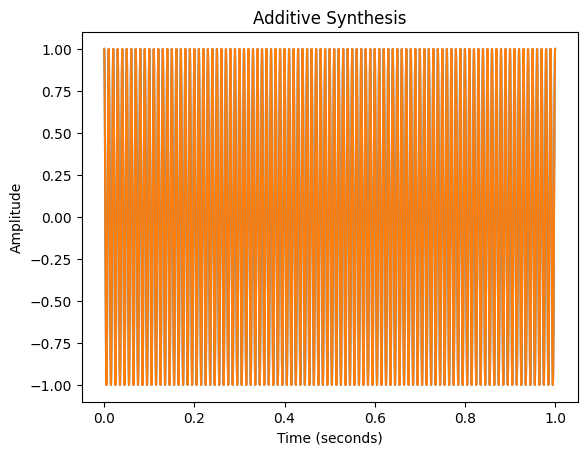

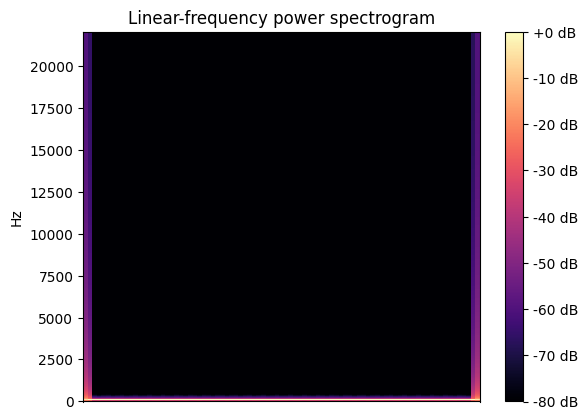

In [29]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

sig = visualizeWaveforms(frequency,samplingRate,numHarmonics,waveType,winSize,specType)
IPython.display.Audio(data=sig,rate=samplingRate)

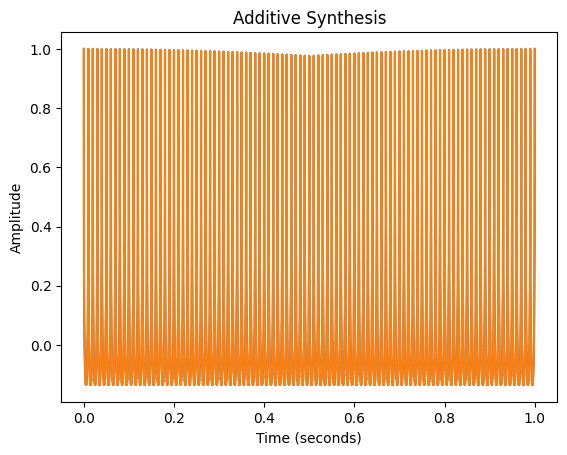

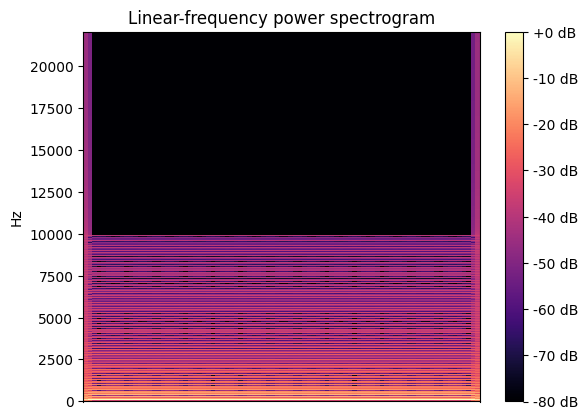

In [30]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

sig = visualizeWaveforms(frequency,samplingRate,numHarmonics,waveType,winSize,specType)
IPython.display.Audio(data=sig,rate=samplingRate)

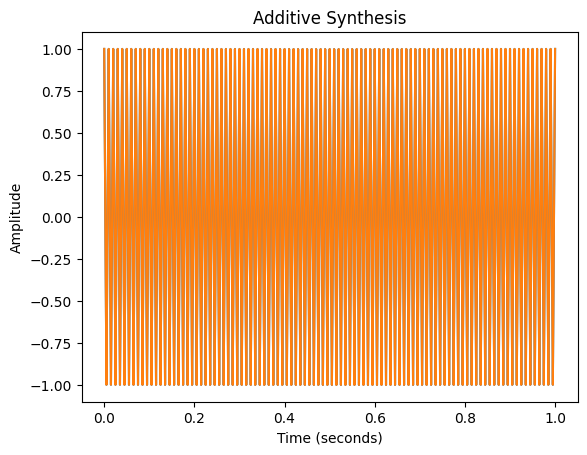

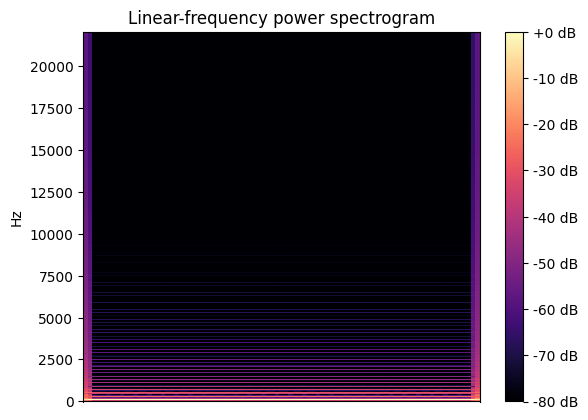

In [31]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

sig = visualizeWaveforms(frequency,samplingRate,numHarmonics,waveType,winSize,specType)
IPython.display.Audio(data=sig,rate=samplingRate)

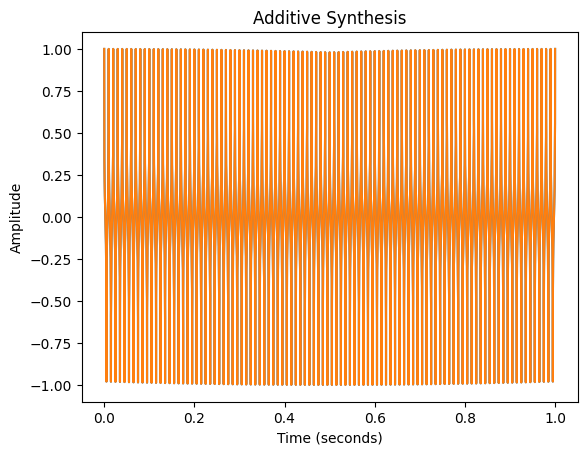

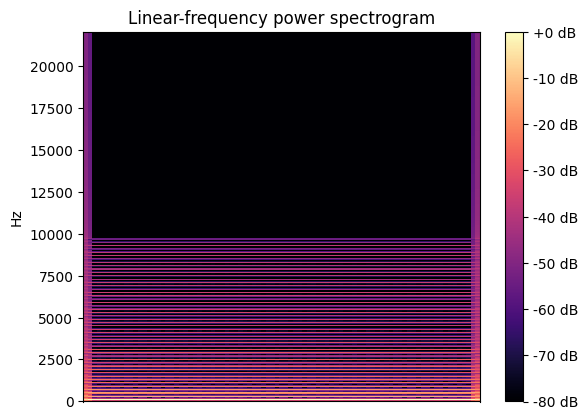

In [32]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

sig = visualizeWaveforms(frequency,samplingRate,numHarmonics,waveType,winSize,specType)
IPython.display.Audio(data=sig,rate=samplingRate)